## **Introduzione**

La seguente analisi è stata effettuata utilizzando un dataset che raccoglie i dati sui crimini registrati nella città di **Baltimora (Maryland, USA)** tra gli anni 2010 e 2017.
Il dataset contiene informazioni dettagliate su ogni evento criminale, tra cui **data, ora, tipologia di reato, localizzazione geografica, distretto di polizia e coordinate GPS**, coprendo un ampio periodo temporale.

L'obiettivo dell'analisi è quello di effettuare una clusterizzazione dei distretti di polizia basati sui loro profili di criminalità, utilizzando algoritmi di clustering come **K-Means**.

Per l'analisi verranno utilizzate librerie Python come **pandas, matplotlib, seaborn, numpy, scipy e sklearn**, che consentiranno di effettuare una **pulizia accurata dei dati, un'analisi esplorativa (EDA) e la modellazione del modello di clustering**.

**N.B.**: Per questioni di compatibilità con le versioni delle librerie, si consiglia di utilizzare la versione **3.12.4** di Python.

In [2]:
# Installazione dei pacchetti necessari
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

### **Import del dataset**

Si inizia l'analisi importando il dataset in formato `.csv`, disponibile al seguente link ufficiale:
🔗 [City of Baltimore Crime Data](https://data.world/data-society/city-of-baltimore-crime-data)

Per avere una visualizzazione piu' dettagliata del dataset, si consiglia di visionare il file `timeseries.ipynb`, che contiene un'analisi delle feature del dataset.

## Pulizia e preprocessing del dataset

Prima di applicare gli algoritmi di clustering, il dataset viene ripulito e trasformato in modo da ottenere un insieme di feature coerente, completo e utilizzabile dai modelli.

In questa fase:

- **Rimuoviamo** colonne che non useremo nell’analisi (ad esempio informazioni testuali o identificative che non entrano nel clustering).
- Convertiamo `CrimeTime` in **ora** (0–23) e creiamo una variabile più semplice, `HourBin`, che divide la giornata in 4 fasce:
  - `Night` (0–5)
  - `Morning` (6–11)
  - `Afternoon` (12–17)
  - `Evening` (18–23)
- Estraiamo `Latitude` e `Longitude` dalla colonna `Location 1` e poi eliminiamo la colonna originale.
- Puliamo la colonna `Description` rimuovendo spazi superflui.
- Uniformiamo i valori di `Inside/Outside` mappandoli in due categorie chiare: **Inside** e **Outside**.
- Eliminiamo le righe con valori mancanti (`dropna`) per evitare problemi nelle fasi successive.

Alla fine di questi passaggi, otteniamo un dataset “pulito” e pronto per le trasformazioni successive (encoding, scaling) e per il clustering.


In [3]:
# Lettura il dataset CSV
df = pd.read_csv("CrimeData.csv")

# Rimozione colonne non necessarie
df = df.drop(columns=['CrimeDate', 'CrimeCode','Location', 'District', 'Neighborhood','Total Incidents', 'Post'], axis=1)

# Conversione colonna "CrimeTime"
df['CrimeTime'] = pd.to_datetime(df['CrimeTime'], format='%H:%M:%S', errors='coerce').dt.hour

# Estrazione coordinate
df[['Latitude', 'Longitude']] = df['Location 1'].str.extract(r'\((.*), (.*)\)').astype(float)
df = df.drop(columns=['Location 1'])

# Uniformizzazione stringhe
df['Description'] = df['Description'].str.strip()

# Standardizzazione più chiara di Inside/Outside
io_map = {'I': 'Inside', 'Inside': 'Inside', 'O': 'Outside', 'Outside': 'Outside'}
df['Inside/Outside'] = df['Inside/Outside'].map(io_map)

# Creazione fasce orarie
bins  = [-0.1, 5, 11, 17, 23]
labs  = ['Night','Morning','Afternoon','Evening']
df['HourBin'] = pd.cut(df['CrimeTime'], bins=bins, labels=labs)
df = df.drop(columns=['CrimeTime'])

# Rimozione delle righe con valori nulli
df = df.dropna()

# Visualizzazione informazioni sul dataset dopo la pulizia
print("Totale righe dopo pulizia:", len(df))
df.head(10)

Totale righe dopo pulizia: 90875


,Description,Inside/Outside,Weapon,Latitude,Longitude,HourBin
1,ROBBERY - COMMERCIAL,Inside,FIREARM,39.28242,-76.59288,Night
5,COMMON ASSAULT,Inside,HANDS,39.37070,-76.56709,Night
6,ROBBERY - COMMERCIAL,Outside,OTHER,39.28624,-76.64455,Night
9,COMMON ASSAULT,Inside,HANDS,39.30340,-76.63842,Morning
11,COMMON ASSAULT,Inside,HANDS,39.30587,-76.67216,Morning
12,COMMON ASSAULT,Inside,HANDS,39.29883,-76.61042,Morning
14,COMMON ASSAULT,Inside,HANDS,39.32120,-76.53906,Morning
17,AGG. ASSAULT,Outside,KNIFE,39.28810,-76.64888,Morning
19,ROBBERY - STREET,Outside,FIREARM,39.31249,-76.64539,Night
20,ROBBERY - STREET,Outside,FIREARM,39.31249,-76.64539,Night


### Encoding delle variabili categoriche e standardizzazione

Le variabili categoriche (`Description`, `Weapon`, `HourBin`, `Inside/Outside`) vengono trasformate in valori numerici tramite **Label Encoding**, mentre tutte le feature vengono successivamente **standardizzate** con `StandardScaler`.

La standardizzazione è fondamentale per K-Means, poiché l’algoritmo si basa sulla distanza euclidea e richiede che tutte le feature contribuiscano in modo comparabile al calcolo delle distanze.

Il dataset risultante (`new_df`) rappresenta quindi lo spazio delle feature su cui verrà applicato direttamente l’algoritmo di clustering.


In [4]:
# Feature categoriche da labelizzare
categorical_cols = ['Description','Weapon','HourBin', 'Inside/Outside']

# Label encoding 
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[f'{col}_encoded'] = le.fit_transform(df[col])
    encoders[col] = le

X = df[['Latitude', 'Longitude', 'Description_encoded', 'Weapon_encoded', 'HourBin_encoded', 'Inside/Outside_encoded']].values

# Standardizzazione delle feature
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

new_df = pd.DataFrame(X_scaled, columns=['Latitude', 'Longitude', 'Description_encoded', 'Weapon_encoded', 'HourBin_encoded', 'Inside/Outside_encoded'])

new_df.head()


,Latitude,Longitude,Description_encoded,Weapon_encoded,HourBin_encoded,Inside/Outside_encoded
0,-0.434227,0.587980,1.357305,-1.327115,1.501239,-0.913462
1,1.111919,1.208409,-0.246169,-0.245826,1.501239,-0.913462
2,-0.367323,-0.655043,1.357305,1.916752,1.501239,1.094736
3,-0.066781,-0.507574,-0.246169,-0.245826,0.601171,-0.913462
4,-0.023521,-1.319256,-0.246169,-0.245826,0.601171,-0.913462


### Scelta del numero ottimale di cluster per K-Means

Poiché K-Means richiede di specificare a priori il numero di cluster `K`, viene effettuata un’analisi preliminare per individuare il valore più appropriato utilizzando due metriche complementari:

- **Metodo Elbow (Inertia)**: misura la somma delle distanze quadratiche dei punti dal centroide del cluster di appartenenza.  
  Un valore ottimale di `K` è spesso associato a un “gomito” nella curva, oltre il quale la riduzione dell’inerzia diventa marginale.

- **Silhouette Score**: valuta quanto ogni punto è simile al proprio cluster rispetto agli altri.  
  Valori più alti indicano cluster più compatti e meglio separati.

L’analisi viene eseguita su un intervallo di valori di `K` compreso tra 2 e 7, utilizzando come input il dataset pulito ottenuto dopo DBSCAN.


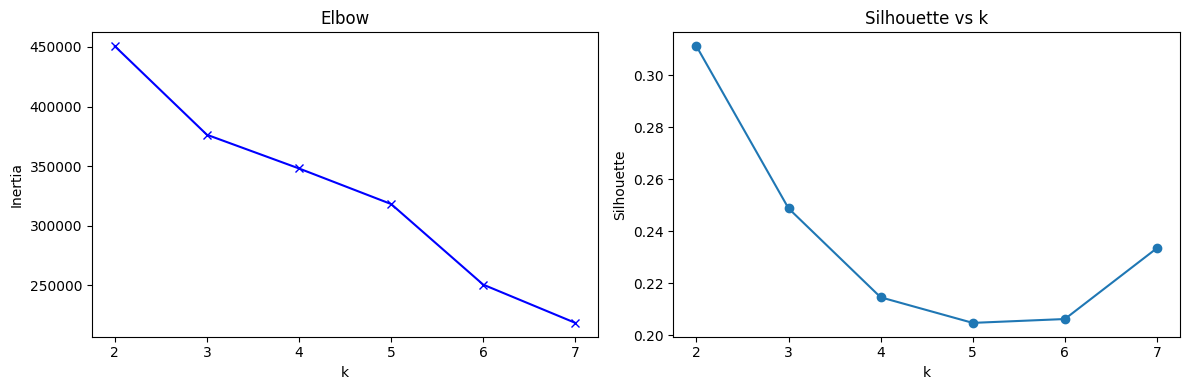

In [4]:
# Elbow Method per determinare il valore ottimale di k
distorsions = []
silhouettes = []
K = range(2, 8)

for k in K:
    km = KMeans(n_clusters=k, n_init='auto', random_state=0)
    labels = km.fit_predict(new_df)
    distorsions.append(km.inertia_)
    silhouettes.append(silhouette_score(new_df, labels))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(K, distorsions, 'bx-')
plt.xlabel('k'); plt.ylabel('Inertia'); plt.title('Elbow')

plt.subplot(1,2,2)
plt.plot(K, silhouettes, 'o-')
plt.xlabel('k'); plt.ylabel('Silhouette'); plt.title('Silhouette vs k')
plt.tight_layout(); plt.show()

### Elbow Method

Dal grafico dell’inerzia si osserva una **diminuzione progressiva e regolare** al crescere di *k*.  
Il calo più significativo avviene passando da **k = 2 a k = 3**, mentre per valori successivi la riduzione diventa meno marcata.

A partire da **k = 4**, l’inerzia continua a diminuire ma senza evidenziare un “gomito” netto, suggerendo che l’aggiunta di ulteriori cluster porta benefici marginali in termini di compattezza.

### Silhouette Score

Il grafico del Silhouette Score mostra:

- il **valore massimo per k = 2**, che indica una buona separazione globale ma con una segmentazione molto grossolana;
- un **calo evidente per k = 3 e k = 4**, seguito da valori più stabili per k maggiori;
- una leggera risalita per **k = 7**, che però non è accompagnata da un chiaro miglioramento strutturale osservabile nell’Elbow Method.

### Considerazioni finali

Nonostante il Silhouette Score sia massimo per *k = 2*, questo valore risulta **poco informativo dal punto di vista interpretativo**, in quanto produce cluster troppo generici.

Il valore **k = 4** rappresenta un buon compromesso tra:
- capacità di segmentazione dei dati,
- stabilità dell’inerzia,
- interpretabilità dei cluster nelle analisi successive.

Per questi motivi si è scelto di proseguire l’analisi utilizzando **k = 4**.

### Esecuzione di K-Means sui dati grezzi

Dopo aver determinato il valore ottimale di `K` tramite Elbow e Silhouette, si esegue ora il clustering **K-Means con K = 4**.

In questa fase:
- ogni evento viene assegnato a uno dei 4 cluster individuati da K-Means;
- le etichette risultanti vengono aggiunte al dataset originale (`df`) in una nuova colonna (`event_cluster`).

L’obiettivo è ottenere una partizione globale degli eventi, così da interpretare i profili dei cluster.


In [5]:
# === Fit KMeans e assegnazione agli eventi ===
k_opt1 = 4
kmeans = KMeans(n_clusters=k_opt1, n_init='auto', random_state=0)
labels = kmeans.fit_predict(new_df)

df_kmeans = df.copy()
df_kmeans['event_cluster'] = labels
# Conteggio dei valori per ogni cluster
print(df_kmeans['event_cluster'].value_counts().sort_index())
df_kmeans.head(10)

event_cluster
0    36267
1    13397
2    24364
3    16847
Name: count, dtype: int64


,Description,Inside/Outside,Weapon,Latitude,Longitude,HourBin,Description_encoded,Weapon_encoded,HourBin_encoded,Inside/Outside_encoded,event_cluster
1,ROBBERY - COMMERCIAL,Inside,FIREARM,39.28242,-76.59288,Night,4,0,3,0,2
5,COMMON ASSAULT,Inside,HANDS,39.37070,-76.56709,Night,1,1,3,0,2
6,ROBBERY - COMMERCIAL,Outside,OTHER,39.28624,-76.64455,Night,4,3,3,1,3
9,COMMON ASSAULT,Inside,HANDS,39.30340,-76.63842,Morning,1,1,2,0,2
11,COMMON ASSAULT,Inside,HANDS,39.30587,-76.67216,Morning,1,1,2,0,2
12,COMMON ASSAULT,Inside,HANDS,39.29883,-76.61042,Morning,1,1,2,0,2
14,COMMON ASSAULT,Inside,HANDS,39.32120,-76.53906,Morning,1,1,2,0,2
17,AGG. ASSAULT,Outside,KNIFE,39.28810,-76.64888,Morning,0,2,2,1,3
19,ROBBERY - STREET,Outside,FIREARM,39.31249,-76.64539,Night,6,0,3,1,1
20,ROBBERY - STREET,Outside,FIREARM,39.31249,-76.64539,Night,6,0,3,1,1


#### Distribuzione degli eventi per cluster

Il numero di eventi assegnati a ciascun cluster è il seguente:

- **Cluster 0**: 36.267 eventi  
- **Cluster 1**: 13.397 eventi  
- **Cluster 2**: 24.364 eventi  
- **Cluster 3**: 16.847 eventi  

La distribuzione risulta **non perfettamente uniforme**, ma comunque priva di cluster estremamente piccoli o residuali. Tutti i cluster contengono una quota significativa di eventi, indicando che K-Means ha suddiviso il dataset in gruppi strutturalmente rilevanti.

---

#### Interpretazione

L’assenza di cluster molto ridotti suggerisce che:
- il clustering sui dati grezzi tende a **modellare le macro-differenze** presenti nel dataset;
- eventi meno frequenti o atipici vengono comunque assegnati a un cluster esistente, anziché essere isolati.

Questo comportamento è coerente con la natura di K-Means, che **non prevede l’identificazione esplicita del rumore o degli outlier**, ma forza ogni osservazione ad appartenere a uno dei cluster.

Questa osservazione diventa particolarmente rilevante nel confronto con l’analisi che include DBSCAN, dove una parte degli eventi viene invece esclusa come rumore prima dell’applicazione di K-Means.

### Visualizzazione e interpretazione dei cluster tramite PCA

Per supportare l’interpretazione dei cluster ottenuti con K-Means, viene applicata la **Principal Component Analysis (PCA)** al dataset standardizzato(`new_df`).

La PCA consente di:
- ridurre la dimensionalità dei dati,
- proiettare gli eventi in uno spazio a 2 dimensioni,
- analizzare quali variabili contribuiscono maggiormente alla separazione dei cluster.

È importante sottolineare che la PCA **non viene utilizzata per il clustering**, ma esclusivamente come strumento di analisi e interpretazione dei risultati prodotti da K-Means.

In questa analisi viene mostrata la proiezione sulle **prime due componenti principali**, che spiegano la quota maggiore di varianza complessiva.


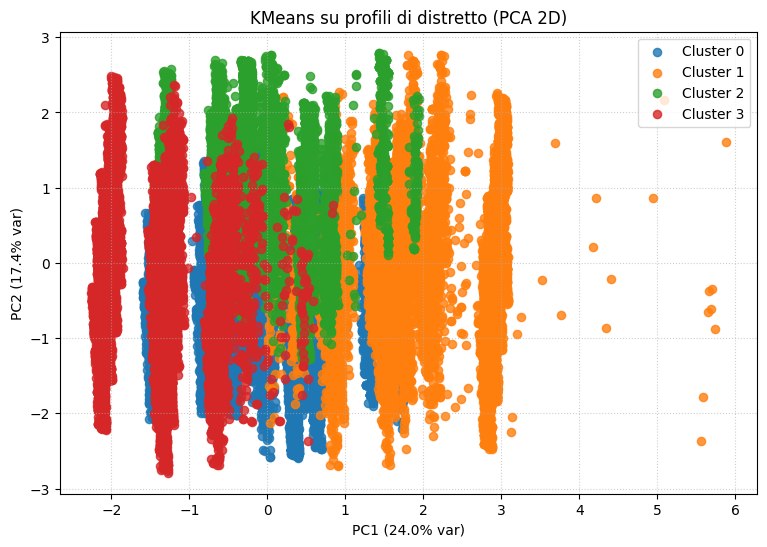

=== PC1 (24.0%) - Cosa sposta i punti a destra/sinistra? ===
--- Spingono a DESTRA (Valori Alti) ---
Description_encoded       0.681552
Inside/Outside_encoded    0.395460
HourBin_encoded           0.076061
Latitude                  0.071252
Longitude                -0.004945
Name: PC1, dtype: float64

--- Spingono a SINISTRA (Valori Bassi) ---
Weapon_encoded           -0.606804
Longitude                -0.004945
Latitude                  0.071252
HourBin_encoded           0.076061
Inside/Outside_encoded    0.395460
Name: PC1, dtype: float64

=== PC2 (17.4%) - Cosa sposta i punti in alto/basso? ===
--- Spingono in ALTO (Valori Alti) ---
HourBin_encoded        0.710886
Longitude              0.638431
Description_encoded    0.001901
Latitude              -0.013333
Weapon_encoded        -0.096922
Name: PC2, dtype: float64

--- Spingono in BASSO (Valori Bassi) ---
Inside/Outside_encoded   -0.278339
Weapon_encoded           -0.096922
Latitude                 -0.013333
Description_encoded    

In [14]:
# === PCA per visualizzare in 2D ===
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(new_df)

plt.figure(figsize=(9,6))
for c in np.unique(labels):
    plt.scatter(
        X_pca[labels == c, 0],
        X_pca[labels == c, 1],
        s=35,
        alpha=0.8,
        label=f'Cluster {c}')

plt.title('KMeans su profili di distretto (PCA 2D)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Crea un DataFrame dei 'loadings' (pesi)
loadings = pd.DataFrame(
    pca.components_.T,  # .T per avere le feature come righe
    columns=['PC1', 'PC2'],
    index=new_df.columns
)

# Stampa le feature più influenti per PC1 (Asse X)
print(f"=== PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%) - Cosa sposta i punti a destra/sinistra? ===")
print("--- Spingono a DESTRA (Valori Alti) ---")
print(loadings['PC1'].sort_values(ascending=False).head(5))
print("\n--- Spingono a SINISTRA (Valori Bassi) ---")
print(loadings['PC1'].sort_values(ascending=True).head(5))

# Stampa le feature più influenti per PC2 (Asse Y)
print(f"\n=== PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%) - Cosa sposta i punti in alto/basso? ===")
print("--- Spingono in ALTO (Valori Alti) ---")
print(loadings['PC2'].sort_values(ascending=False).head(5))
print("\n--- Spingono in BASSO (Valori Bassi) ---")
print(loadings['PC2'].sort_values(ascending=True).head(5))

## Analisi tramite PCA (Principal Component Analysis)

Per facilitare l’interpretazione dei cluster individuati da K-Means, è stata applicata una **PCA a due componenti**, con l’obiettivo di:
- ridurre la dimensionalità del dataset,
- analizzare quali variabili contribuiscono maggiormente alla separazione dei dati,
- visualizzare la distribuzione dei cluster nello spazio delle componenti principali.

Le prime due componenti spiegano complessivamente circa il **41.4\% della varianza totale**:
- **PC1**: 24.0\%
- **PC2**: 17.4\%

### Interpretazione della prima componente principale (PC1)

La **PC1** rappresenta l’asse di separazione più rilevante nel dataset.

I fattori che spingono maggiormente i punti verso destra (valori alti di PC1) sono:
- **Description\_encoded**, che indica il tipo di reato;
- **Inside/Outside\_encoded**, che distingue tra eventi avvenuti all’interno o all’esterno;
- in misura minore, la fascia oraria (**HourBin\_encoded**).

Al contrario, i punti con valori bassi di PC1 (verso sinistra) sono caratterizzati principalmente da:
- **Weapon\_encoded**, che assume un ruolo opposto rispetto alla tipologia di reato.

Questo suggerisce che la prima componente separa gli eventi soprattutto in base alla **combinazione tra tipologia di reato, contesto (inside/outside) e tipo di arma utilizzata**.

### Interpretazione della seconda componente principale (PC2)

La **PC2** è fortemente influenzata da:
- **HourBin\_encoded**, che rappresenta la fascia oraria del reato;
- **Longitude**, che introduce una componente spaziale nella separazione verticale dei punti.

I valori alti di PC2 sono associati principalmente a specifiche fasce orarie, mentre i valori bassi risultano più legati alla variabile **Inside/Outside**.

Questo indica che la seconda componente cattura una **dinamica temporale e spaziale**, distinguendo eventi che avvengono in momenti diversi della giornata e in contesti differenti.

### Considerazioni sulla visualizzazione

La proiezione bidimensionale mostra una **parziale sovrapposizione dei cluster**, che è coerente con:
- l’elevata dimensionalità originale del dataset,
- la natura categorica delle variabili utilizzate,
- la complessità intrinseca dei dati sui reati.

Pertanto, la PCA non viene utilizzata come strumento decisionale per la scelta dei cluster, ma come **supporto interpretativo**, utile soprattutto per comprendere **quali variabili guidano la separazione dei dati** osservata da K-Means.


### Costruzione dei profili dei cluster

I cluster ottenuti con K-Means sono stati calcolati utilizzando feature numeriche (coordinate + variabili categoriche codificate e standardizzate).  
Tuttavia, per interpretare **il significato reale dei cluster** è necessario tornare a variabili leggibili e confrontabili, come le categorie originali di:

- tipo di reato (`Description`)
- arma (`Weapon`)
- fascia oraria (`HourBin`)
- contesto (`Inside/Outside`)

In questa fase si procede quindi a:

1. eliminare le colonne `_encoded` (utili solo per il clustering numerico);
2. applicare il **One-Hot Encoding** alle colonne categoriche originali;
3. ottenere una rappresentazione binaria (0/1) per ogni categoria, che consente poi di calcolare facilmente **frequenze/percentuali** per cluster.

L’obiettivo è preparare i dati per calcolare, in seguito, la **media per cluster** delle colonne one-hot: tale media corrisponderà alla percentuale di eventi del cluster che appartiene a ciascuna categoria (profilo del cluster).


In [7]:
# Pulizia del dataframe finale con i cluster di Kmeans
# elimino le colonne _encoded e la colonna cluster
cleaned_clustered_values = df_kmeans.drop(columns=['Description_encoded', 'Weapon_encoded', 'HourBin_encoded', 'Inside/Outside_encoded'])

#salvo il dataframe pulito con i cluster in un nuovo CSV
cleaned_clustered_values.to_csv("CrimeData_Clustered_withKmeans_withoutFilter.csv", index=False)

# Categorie per fare il profilo
cat_cols = ['Description','Weapon','HourBin', 'Inside/Outside']

# One-hot encoding (dummies)
dummies = pd.get_dummies(cleaned_clustered_values[cat_cols], drop_first=False)

# Concatenazione dei dummies al dataframe pulito
cleaned_clustered_values = pd.concat([cleaned_clustered_values['event_cluster'].reset_index(drop=True), dummies.reset_index(drop=True)], axis=1)

cleaned_clustered_values.head(10)


,event_cluster,Description_AGG. ASSAULT,Description_COMMON ASSAULT,Description_RAPE,Description_ROBBERY - CARJACKING,Description_ROBBERY - COMMERCIAL,Description_ROBBERY - RESIDENCE,Description_ROBBERY - STREET,Weapon_FIREARM,Weapon_HANDS,Weapon_KNIFE,Weapon_OTHER,HourBin_Night,HourBin_Morning,HourBin_Afternoon,HourBin_Evening,Inside/Outside_Inside,Inside/Outside_Outside
0,2,False,False,False,False,True,False,False,True,False,False,False,True,False,False,False,True,False
1,2,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False
2,3,False,False,False,False,True,False,False,False,False,False,True,True,False,False,False,False,True
3,2,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False
4,2,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False
5,2,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False
6,2,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False
7,3,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True
8,1,False,False,False,False,False,False,True,True,False,False,False,True,False,False,False,False,True
9,1,False,False,False,False,False,False,True,True,False,False,False,True,False,False,False,False,True


A questo punto il dataset contiene:
- la colonna `event_cluster`,
- e un insieme di colonne binarie ottenute dal One-Hot Encoding.

Ogni riga rappresenta un evento; le colonne one-hot valgono 1 se l’evento appartiene a quella categoria, altrimenti 0.

Il passo successivo consiste nel **raggruppare per `event_cluster` e calcolare la media** delle colonne one-hot:  
la media di una colonna binaria corrisponde alla **percentuale** di eventi del cluster che appartiene a quella categoria, ottenendo così un **profilo interpretabile del cluster**.


### Creazione dei profili percentuali dei cluster

Dopo aver trasformato le variabili categoriche in colonne binarie tramite **One-Hot Encoding**, è possibile costruire un profilo sintetico per ciascun cluster K-Means.

Il principio è semplice:  
poiché ogni colonna one-hot vale **1** se l’evento appartiene a quella categoria e **0** altrimenti, la **media** di quella colonna all’interno di un cluster corrisponde alla **percentuale di eventi** del cluster che appartiene a quella categoria.

Esempio:
- se in un cluster la colonna `Weapon_HANDS` ha media `0.77`, significa che **il 77% degli eventi** di quel cluster coinvolge “Hands”.

Per ottenere questi profili, si raggruppano i dati per `event_cluster` e si calcola la media delle colonne binarie.


In [16]:
# Aggrego per cluster calcolando i profili percentuali

# Unità di aggregazione: Cluster
profile = cleaned_clustered_values.groupby('event_cluster', as_index=True).mean()

print(profile.round(3))

               Description_AGG. ASSAULT  Description_COMMON ASSAULT  \
event_cluster                                                         
0                                 0.185                       0.788   
1                                 0.000                       0.001   
2                                 0.230                       0.740   
3                                 0.884                       0.000   

               Description_RAPE  Description_ROBBERY - CARJACKING  \
event_cluster                                                       
0                         0.000                             0.004   
1                         0.000                             0.044   
2                         0.000                             0.006   
3                         0.087                             0.006   

               Description_ROBBERY - COMMERCIAL  \
event_cluster                                     
0                                         0.023   
1    

### Interpretazione dei profili dei cluster (percentuali)

La tabella risultante descrive, per ciascun cluster, la distribuzione percentuale delle categorie principali (tipo di reato, arma, fascia oraria e contesto Inside/Outside).  
Dall’output emergono profili molto distinti:

### Cluster 0

Il **Cluster 0** è caratterizzato principalmente da:
- **Common Assault** (circa 79\%) e **Agg. Assault**;
- utilizzo prevalente di **mani come armi (Hands)**;
- eventi concentrati soprattutto nelle **fasce pomeridiane e serali**;
- una leggera prevalenza di eventi **avvenuti all’interno**.

Questo cluster rappresenta quindi reati di aggressione, generalmente non armati, distribuiti nel corso della giornata, con una moderata incidenza in ambienti chiusi.

### Cluster 1

Il **Cluster 1** mostra una configurazione nettamente diversa:
- forte presenza di **Robbery – Street** (oltre il 75\%);
- utilizzo predominante di **armi da fuoco**;
- eventi distribuiti soprattutto tra **sera e notte**;
- prevalenza di eventi **all’esterno**.

Questo cluster identifica un profilo tipico di **rapine armate in strada**, con un’elevata componente di rischio.

### Cluster 2

Il **Cluster 2** è dominato da:
- **Common Assault** e **Agg. Assault**;
- uso prevalente di **mani come armi (Hands)** e, in misura minore, coltelli;
- eventi concentrati principalmente nelle **ore notturne e mattutine**;
- una forte prevalenza di eventi **all’interno**.

Rispetto al Cluster 0, questo cluster rappresenta una tipologia di aggressioni simili, ma con una **diversa distribuzione temporale** e una maggiore incidenza in ambienti chiusi.

### Cluster 3

Il **Cluster 3** presenta un profilo distinto:
- elevata incidenza di **Agg. Assault** e **Rape**;
- utilizzo frequente di **armi non convenzionali o coltelli**;
- distribuzione temporale più uniforme, con una maggiore presenza nella **fascia serale**;
- distribuzione bilanciata tra eventi **inside** e **outside**.

Questo cluster raccoglie eventi più eterogenei, accomunati da una maggiore gravità e da modalità operative differenti rispetto agli altri cluster.

### Considerazioni generali

L’aggregazione per cluster evidenzia come K-Means abbia individuato gruppi di eventi **coerenti e interpretabili**.

Questi profili costituiscono la base per un’analisi comparativa più approfondita, che verrà ulteriormente raffinata tramite la visualizzazione mediante heatmap e l’analisi del lift.

### Analisi descrittiva dei cluster tramite heatmap dei profili percentuali

La heatmap consente di:
- confrontare visivamente i cluster tra loro,
- individuare rapidamente le feature **più frequenti** all’interno di ciascun gruppo,
- ottenere una prima intuizione sulle differenze strutturali tra i cluster.

È importante sottolineare che questa analisi riflette **le frequenze assolute** delle variabili, senza tenere conto della loro rarità o diffusione nel dataset complessivo.


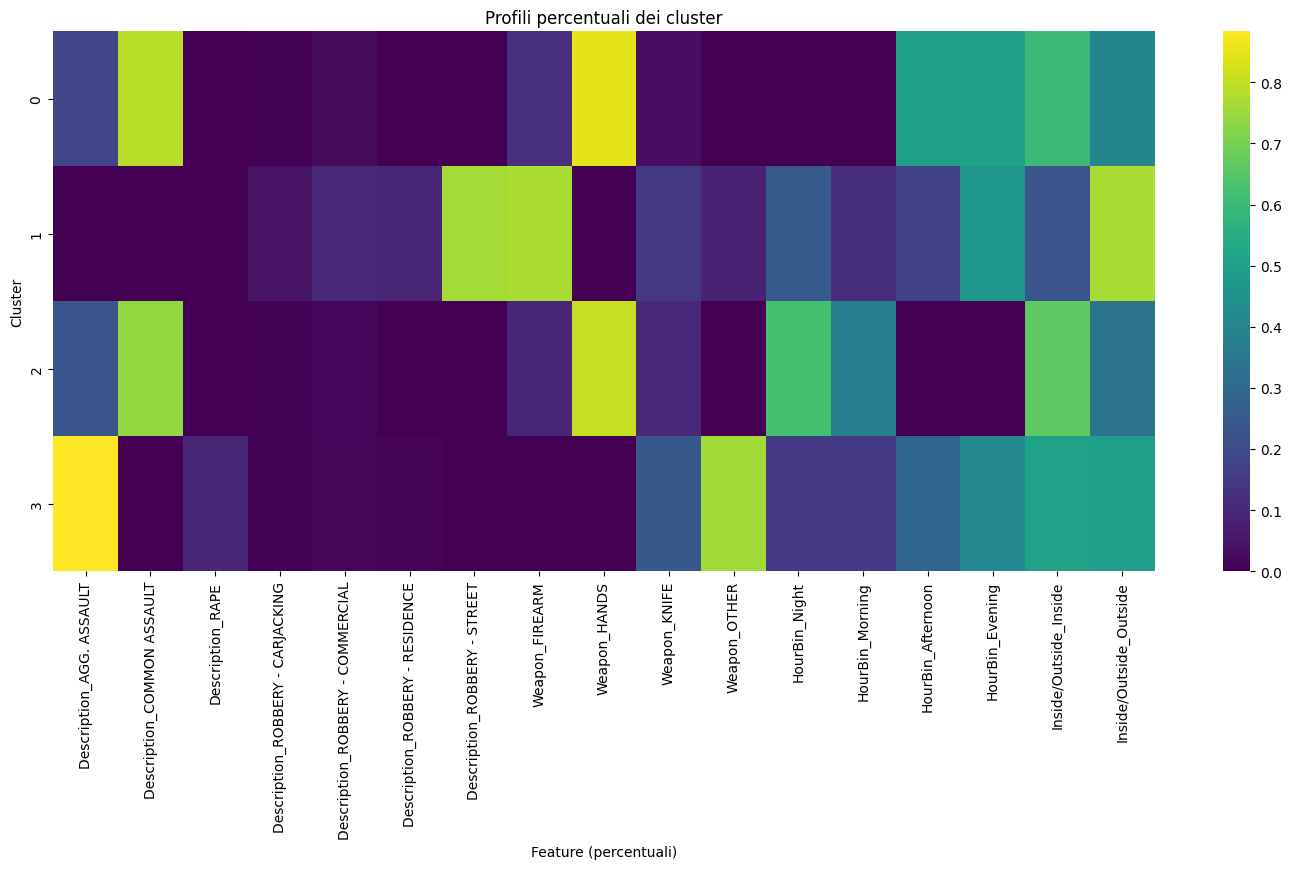

In [19]:
# === Heatmap dei centroidi per confronto rapido ===
plt.figure(figsize=(min(16, 0.5*len(profile.columns)+6), 1.2*k_opt1+4))
sns.heatmap(
    profile,
    cmap='viridis',
    annot=False,
    cbar=True
)
plt.title('Profili percentuali dei cluster')
plt.xlabel('Feature (percentuali)')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

## Analisi visiva dei profili di cluster tramite heatmap

La heatmap mostra i **profili percentuali dei cluster**, ottenuti aggregando i dati e calcolando la media delle variabili categoriali per ciascun cluster.  
Ogni cella rappresenta quindi la **frequenza relativa** di una determinata categoria all’interno del cluster.

Questa visualizzazione consente un confronto immediato tra i cluster, evidenziando similitudini e differenze nelle tipologie di reato, nell’uso delle armi, nella distribuzione temporale e nel contesto (inside/outside).

### Cluster 0

Il **Cluster 0** è caratterizzato da:
- una forte prevalenza di **Common Assault**;
- utilizzo quasi esclusivo di **armi (Hands)**;
- concentrazione degli eventi nelle **fasce pomeridiane e serali**;
- maggiore incidenza di eventi **avvenuti all’interno**.

Il profilo suggerisce reati di aggressione non armata, distribuiti nel corso della giornata, spesso in ambienti chiusi.

### Cluster 1

Il **Cluster 1** mostra un profilo nettamente distinto:
- forte presenza di **Robbery – Street**;
- utilizzo prevalente di **armi da fuoco**;
- eventi concentrati soprattutto in **orario serale e notturno**;
- prevalenza di eventi **all’esterno**.

Questo cluster identifica chiaramente una tipologia di **rapine armate**, con modalità operative più violente rispetto agli altri gruppi.

### Cluster 2

Il **Cluster 2** presenta caratteristiche simili al Cluster 0, ma con differenze rilevanti:
- prevalenza di **Common Assault** e **Agg. Assault**;
- uso predominante di **armi (Hands)**;
- maggiore concentrazione di eventi nelle **ore notturne**;
- forte incidenza di eventi **all’interno**.

Questo cluster rappresenta quindi aggressioni non armate, ma con una **diversa distribuzione temporale** rispetto al cluster 0, maggiormente spostata verso la notte.

### Cluster 3

Il **Cluster 3** si distingue per:
- una forte concentrazione di **Agg. Assault**;
- utilizzo prevalente di **Weapon Other** e **Knife**;
- distribuzione temporale più uniforme, con una maggiore presenza nelle **fasce serali**;
- una distribuzione bilanciata tra eventi **inside** e **outside**.

Il profilo indica una tipologia di eventi più eterogenea, potenzialmente associata a situazioni di maggiore gravità.



### Analisi del Lift: individuazione delle caratteristiche distintive dei cluster

L’analisi basata sulle percentuali (medie delle colonne one-hot) permette di comprendere quali categorie sono più frequenti all’interno di ciascun cluster. Tuttavia, questo approccio presenta un limite importante:  
le categorie molto comuni a livello globale tendono a dominare la rappresentazione, mentre eventi meno frequenti ma altamente caratterizzanti rischiano di essere sottovalutati.

Per superare questo limite, viene introdotta l’**analisi del Lift**.

Il Lift confronta, per ogni feature e per ogni cluster, la sua incidenza nel cluster rispetto alla **media globale dell’intero dataset**. In questo modo è possibile identificare non solo ciò che è frequente, ma soprattutto ciò che è **sovra-rappresentato** in un cluster rispetto al comportamento medio complessivo.

Formalmente:
- **Lift > 1** indica che una feature è più presente nel cluster rispetto alla media globale;
- **Lift = 1** indica una presenza in linea con la media;
- **Lift < 1** indica una sotto-rappresentazione.

Questa analisi consente di assegnare una “firma” chiara a ciascun cluster, evidenziandone le peculiarità reali.


In [20]:
# === LIFT rispetto alla media globale ===
global_mean = profile.mean()

lift = profile.copy()
for col in lift.columns:
    baseline = global_mean[col] if global_mean[col] != 0 else 1e-9
    lift[col] = lift[col] / baseline  # >1 = sopra la media globale

for c in lift.index:
    print(f'\n=== {c}: feature con lift più alto ===')
    print(
        lift.loc[c]
        .sort_values(ascending=False)
        .head(15)
        .round(2))


=== 0: feature con lift più alto ===
HourBin_Afternoon                   2.07
Description_COMMON ASSAULT          2.06
Weapon_HANDS                        2.05
HourBin_Evening                     1.46
Inside/Outside_Inside               1.19
Inside/Outside_Outside              0.81
Description_AGG. ASSAULT            0.57
Description_ROBBERY - COMMERCIAL    0.56
Weapon_FIREARM                      0.48
Description_ROBBERY - CARJACKING    0.29
Weapon_KNIFE                        0.26
Description_ROBBERY - RESIDENCE     0.00
Description_ROBBERY - STREET        0.00
Weapon_OTHER                        0.00
HourBin_Night                       0.00
Name: 0, dtype: float64

=== 1: feature con lift più alto ===
Description_ROBBERY - STREET        4.00
Description_ROBBERY - RESIDENCE     3.52
Weapon_FIREARM                      3.14
Description_ROBBERY - CARJACKING    2.93
Description_ROBBERY - COMMERCIAL    2.56
Inside/Outside_Outside              1.54
HourBin_Evening                     1.3

### Interpretazione dell’analisi del Lift

L’analisi del **Lift** consente di interpretare i cluster andando oltre le percentuali assolute, evidenziando **quali caratteristiche risultano sovra- o sotto-rappresentate rispetto alla media globale del dataset**.

Questa lettura è particolarmente importante nel caso in cui si utilizzi l’intero dataset senza una fase di filtraggio preliminare, poiché la distribuzione complessiva dei dati tende a essere dominata dagli eventi più frequenti.

---
### Cluster 0

Il **Cluster 0** è fortemente caratterizzato da:
- **Common Assault** (lift ≈ 2.06);
- utilizzo di **armi (Hands)** (lift ≈ 2.05);
- eventi concentrati nel **pomeriggio** (lift ≈ 2.07) e in **fascia serale**;
- leggera prevalenza di eventi **all’interno**.

Il lift conferma che questo cluster rappresenta aggressioni non armate, distribuite prevalentemente nelle ore pomeridiane e serali, con una dinamica relativamente meno violenta rispetto ad altri cluster.

### Cluster 1

Il **Cluster 1** mostra un profilo estremamente netto:
- **Robbery – Street** (lift = 4.00);
- **Robbery – Residence** (lift ≈ 3.52);
- **Robbery – Carjacking** e **Robbery – Commercial** fortemente sovra-rappresentate;
- utilizzo prevalente di **armi da fuoco** (lift ≈ 3.14);
- maggiore incidenza di eventi **all’esterno**.

Questo cluster identifica chiaramente una tipologia di **rapine armate**, distinguendosi in modo marcato da tutti gli altri gruppi.

### Cluster 2

Il **Cluster 2** è caratterizzato da:
- eventi concentrati in **orario notturno** e **mattutino** (lift > 2);
- forte presenza di **Common Assault** e uso di **armi improprie (Hands)**;
- prevalenza di eventi **all’interno**.

Il lift evidenzia come questo cluster rappresenti aggressioni non armate simili al Cluster 0, ma con una **diversa collocazione temporale**, maggiormente spostata verso la notte e le prime ore del giorno.

### Cluster 3

Il **Cluster 3** si distingue nettamente per:
- **Rape** (lift = 4.00), evento raro ma fortemente concentrato;
- utilizzo di **Weapon Other** (lift ≈ 3.60) e **Knife** (lift ≈ 1.85);
- forte presenza di **Agg. Assault** (lift ≈ 2.72);
- distribuzione temporale più equilibrata, con una leggera prevalenza nelle ore pomeridiane e serali.

Questo cluster rappresenta una tipologia di eventi meno frequente ma **particolarmente distintiva**, che risulterebbe poco visibile analizzando solo le frequenze assolute.

### Considerazioni finali sull’analisi del lift

L’analisi del lift consente di:
- confermare le strutture emerse dalla heatmap;
- evidenziare caratteristiche specifiche che sarebbero altrimenti mascherate dalla frequenza globale;
- fornire una **“personalità” chiara e interpretabile** a ciascun cluster.

In particolare, il lift risulta fondamentale per identificare cluster associati a eventi rari ma significativi, rendendo l’analisi complessiva più informativa e robusta.

